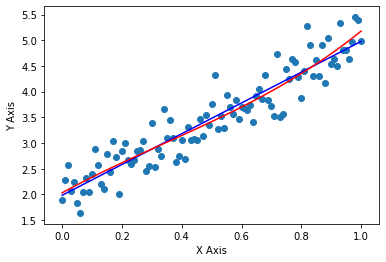

Least Squares MSE: 0.10631283138253524
Polynomial MSE: 0.10210381083543131
Least Squares R2: 0.8776514609206421
Polynomial R2: 0.8824953495481607
Polynomial fit is better


In [37]:
import numpy as np ##CHATGPT utilized for graphing and part of calculation, but slides provided most of the work 
import matplotlib.pyplot as plt

X = np.arange(0, 1.01, 0.01)

slope = 3
yIntercept = 2

Y = slope * X + yIntercept + np.random.normal(0, 0.3, len(X))

A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]

Y_ls = m*X + c

polynom = np.polyfit(X, Y, 3)
Y_polynom = np.polyval(polynom, X)

plt.scatter(X, Y)

plt.plot(X, Y_ls, color="blue", label="Least Squares")
plt.plot(X, Y_polynom, color="red", label="Cubic Polynomial Fit")

plt.xlabel("X Axis")
plt.ylabel("Y Axis")

plt.show()

mse_ls = np.mean((Y - Y_ls)**2)
mse_polynom = np.mean((Y - Y_polynom)**2)

print("Least Squares MSE:", mse_ls)
print("Polynomial MSE:", mse_polynom)

ss_tot = np.sum((Y - np.mean(Y))**2)

ss_res_ls = np.sum((Y - Y_ls)**2)
ss_res_polynom = np.sum((Y - Y_polynom)**2)

r2_ls = 1 - ss_res_ls/ss_tot
poly2 = 1 - ss_res_polynom/ss_tot

print("Least Squares R2:", r2_ls)
print("Polynomial R2:", poly2)

if poly2 > r2_ls:
    print("Polynomial fit is better")

if r2_ls > poly2:
    print("Least Squares fit is better")

Degree: 1
MSE: 0.09235914090572726
R2: 0.9015381161812437


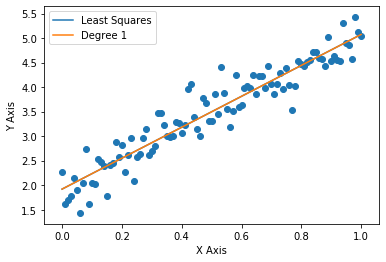

Degree: 2
MSE: 0.08873083865545885
R2: 0.905406162929209


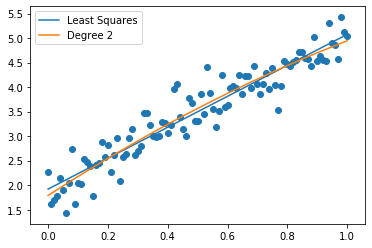

Degree: 3
MSE: 0.08690664190371952
R2: 0.9073508957068303


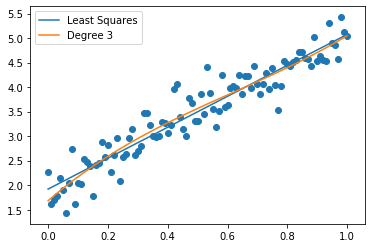

Degree: 4
MSE: 0.08507971663755236
R2: 0.909298537288799


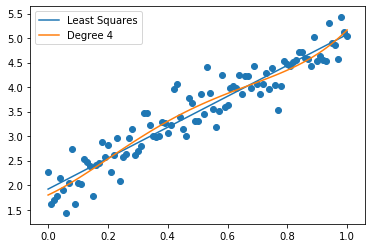

Degree: 5
MSE: 0.08486333036318335
R2: 0.9095292215502371


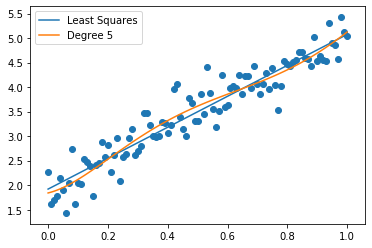

Degree: 6
MSE: 0.0848383076234475
R2: 0.9095558976980286


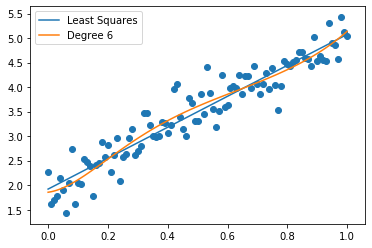

Degree: 7
MSE: 0.08467617991029708
R2: 0.9097287381976203


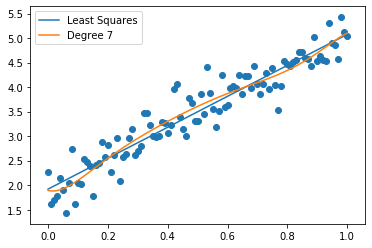

Degree: 8
MSE: 0.08420563532506033
R2: 0.9102303745903887


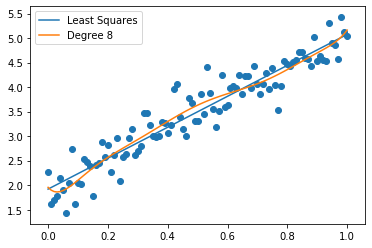

Degree: 9
MSE: 0.0839866528629126
R2: 0.9104638265858803


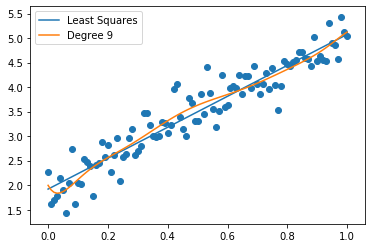

Degree: 10
MSE: 0.08274994612173826
R2: 0.9117822502337537


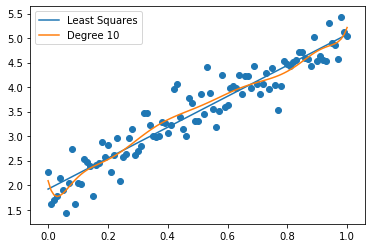

In [38]:
## PART B Chatgpt utilized for error with graph as in using MATPLOTLIB with color coded + bug fix 
import numpy as np
import matplotlib.pyplot as plt

X = np.arange(0, 1.01, 0.01)

slope = 3
yIntercept = 2

Y = slope * X + yIntercept + np.random.normal(0, 0.3, len(X))

A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]

Y_ls = m*X + c



plt.xlabel("X Axis")
plt.ylabel("Y Axis")

for degree in range(1,11):
    
    plt.scatter(X, Y)
    plt.plot(X, Y_ls, label="Least Squares")
    polynom = np.polyfit(X, Y, degree)
    Y_polynom = np.polyval(polynom, X)

    mse = np.mean((Y - Y_polynom)**2)

    varTotal = np.sum((Y - np.mean(Y))**2)
    remainingErr = np.sum((Y - Y_polynom)**2)

    r2 = 1 - remainingErr/varTotal

    print("Degree:", degree)
    print("MSE:", mse)
    print("R2:", r2)

    plt.plot(X, Y_polynom, label=f"Degree {degree}")
    plt.legend()
    plt.show()



Degree: 1
Vandermond MSE: 0.09235914090572728
Vandermond R2: 0.9015381161812437


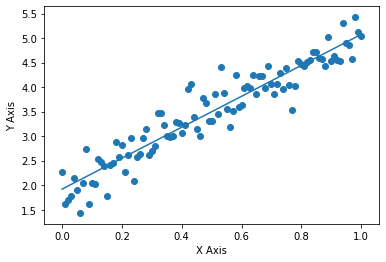

Degree: 2
Vandermond MSE: 0.08873083865545889
Vandermond R2: 0.905406162929209


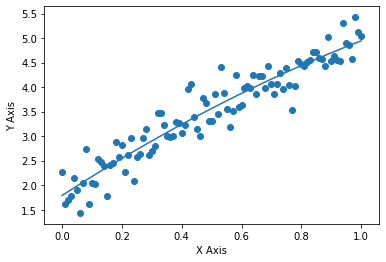

Degree: 3
Vandermond MSE: 0.0869066419037195
Vandermond R2: 0.9073508957068303


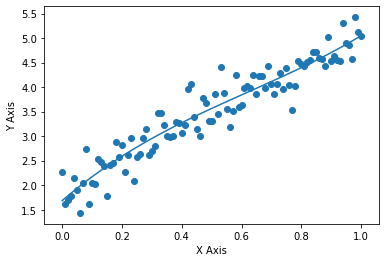

Degree: 4
Vandermond MSE: 0.08507971663755234
Vandermond R2: 0.909298537288799


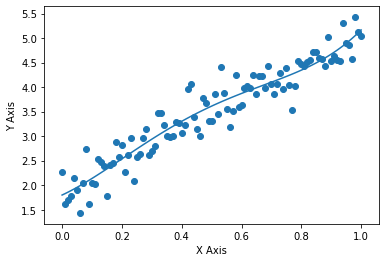

Degree: 5
Vandermond MSE: 0.08486333036318336
Vandermond R2: 0.9095292215502371


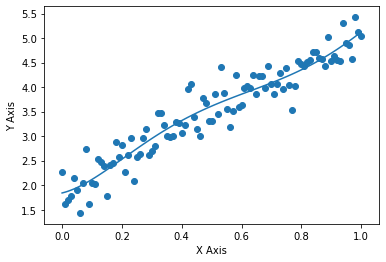

Degree: 6
Vandermond MSE: 0.08483830762344738
Vandermond R2: 0.9095558976980287


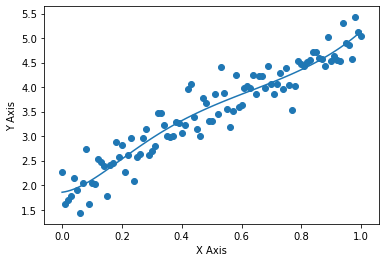

Degree: 7
Vandermond MSE: 0.08467617991029806
Vandermond R2: 0.9097287381976193


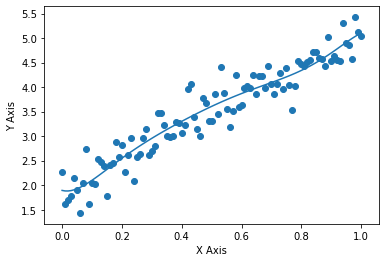

Degree: 8
Vandermond MSE: 0.08420563532506936
Vandermond R2: 0.910230374590379


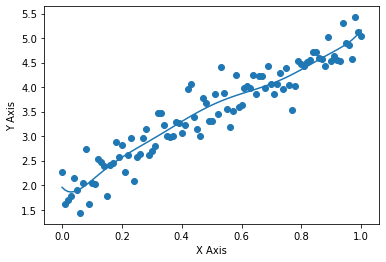

Degree: 9
Vandermond MSE: 0.0839866528629425
Vandermond R2: 0.9104638265858485


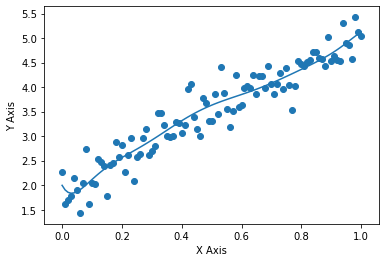

Degree: 10
Vandermond MSE: 0.08274994612205762
Vandermond R2: 0.9117822502334132


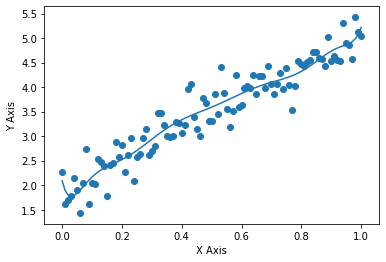

In [39]:
## PART C AIutilized for Vander function, specifically in the actual implemntation along with slides

import numpy as np
import matplotlib.pyplot as plt

for degree in range(1,11):

    vandermond = np.vander(X, degree+1)

    coeff = np.linalg.lstsq(vandermond, Y, rcond=None)[0]

    Y_vandermond = vandermond @ coeff

    mse = np.mean((Y - Y_vandermond)**2)

    varTotal = np.sum((Y - np.mean(Y))**2)
    remainingErr = np.sum((Y - Y_vandermond)**2) ##Missed class, utilized ChATGPT To understand Vadnermond and how to implement, I understand it now 

    r2 = 1 - remainingErr/varTotal

    print("Degree:", degree)
    print("Vandermond MSE:", mse)
    print("Vandermond R2:", r2)

    plt.scatter(X, Y)
    plt.plot(X, Y_vandermond)
    plt.xlabel("X Axis")
    plt.ylabel("Y Axis")
    plt.show()